# Capítulo 26 — Clustering con K-Means

En el cuaderno anterior usamos K-Means como una primera demostración del aprendizaje no supervisado. Ahora estudiaremos con más detalle **cómo construye los grupos**, qué representan sus centroides y por qué la distancia, el escalado y la elección de `k` modifican el resultado.

Retomaremos explícitamente el ejemplo de clientes del capítulo teórico y el mismo conjunto didáctico del Cuaderno 25. No existe una columna `tipo_cliente`: K-Means recibirá variables de comportamiento y propondrá una organización posible.

El recorrido tendrá dos niveles. Primero reconstruiremos el mecanismo del algoritmo en dos dimensiones, paso a paso. Después trabajaremos con cinco variables para comparar cantidades de clusters, construir el método del codo, interpretar perfiles en unidades originales y observar varias limitaciones.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar qué representa un centroide;
- reconstruir la asignación de un punto al centro más cercano;
- describir el ciclo de asignar, recalcular y repetir;
- interpretar `labels_`, `cluster_centers_`, `transform` e `inertia_`;
- mostrar cómo cambia la segmentación al modificar `k`;
- construir e interpretar un gráfico del método del codo;
- aplicar escalado y K-Means dentro de un pipeline;
- describir clusters mediante variables en unidades originales;
- asignar casos nuevos usando los centroides ya aprendidos;
- reconocer formas, outliers y otras situaciones que dificultan el uso de K-Means.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para los cálculos y las tablas, Matplotlib para visualizar los grupos y herramientas de `scikit-learn` para escalar, medir distancias, generar ejemplos y ajustar K-Means.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import pairwise_distances
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Recuperar el ejemplo de clientes

Reconstruiremos el conjunto utilizado en el Cuaderno 25. Las variables se basan en el ejemplo del capítulo teórico: frecuencia de compra, gasto promedio, días desde la última compra, antigüedad y variedad de categorías.

Los patrones fueron preparados para que el funcionamiento resulte visible, pero las etiquetas que se usaron al generar los datos no se conservan. Para el análisis tenemos solamente `X`.


In [2]:
generador = np.random.default_rng(25)


def crear_clientes(
    cantidad,
    frecuencia_media,
    gasto_medio,
    recencia_media,
    antiguedad_media,
    categorias_media,
):
    return pd.DataFrame({
        "frecuencia_compra": generador.normal(
            frecuencia_media, 1.8, cantidad
        ),
        "gasto_promedio": generador.normal(
            gasto_medio, gasto_medio * 0.13, cantidad
        ),
        "dias_ultima_compra": generador.normal(
            recencia_media, max(4, recencia_media * 0.22), cantidad
        ),
        "antiguedad_meses": generador.normal(
            antiguedad_media, 8, cantidad
        ),
        "categorias_compradas": generador.normal(
            categorias_media, 0.8, cantidad
        ),
        "edad": generador.integers(20, 71, cantidad),
    })


datos_clientes = pd.concat([
    crear_clientes(45, 14, 95_000, 9, 32, 5.5),
    crear_clientes(40, 5, 180_000, 28, 20, 3.5),
    crear_clientes(35, 2.5, 52_000, 88, 55, 2.2),
], ignore_index=True)

datos_clientes["frecuencia_compra"] = (
    datos_clientes["frecuencia_compra"].clip(0.5).round(1)
)
datos_clientes["gasto_promedio"] = (
    datos_clientes["gasto_promedio"].clip(10_000).round(-2)
)
datos_clientes["dias_ultima_compra"] = (
    datos_clientes["dias_ultima_compra"].clip(1).round().astype(int)
)
datos_clientes["antiguedad_meses"] = (
    datos_clientes["antiguedad_meses"].clip(1).round().astype(int)
)
datos_clientes["categorias_compradas"] = (
    datos_clientes["categorias_compradas"].clip(1, 8).round().astype(int)
)

datos_clientes = (
    datos_clientes
    .sample(frac=1, random_state=25)
    .reset_index(drop=True)
)
datos_clientes.insert(
    0,
    "cliente",
    [f"CLI-{numero:03d}" for numero in range(1, len(datos_clientes) + 1)],
)

datos_clientes.head(8)


,cliente,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas,edad
0,CLI-001,14.10,"82,400.00",10,19,6,65
1,CLI-002,13.60,"66,600.00",1,23,6,48
2,CLI-003,5.10,"165,000.00",15,31,3,31
3,CLI-004,14.20,"111,900.00",8,26,5,22
4,CLI-005,14.50,"108,000.00",2,24,5,58
5,CLI-006,11.50,"107,900.00",7,49,6,50
6,CLI-007,0.80,"184,000.00",18,20,3,64
7,CLI-008,15.90,"103,700.00",7,28,6,55


In [3]:
variables_comportamiento = [
    "frecuencia_compra",
    "gasto_promedio",
    "dias_ultima_compra",
    "antiguedad_meses",
    "categorias_compradas",
]

X_clientes = datos_clientes[variables_comportamiento]

pd.DataFrame({
    "filas": [X_clientes.shape[0]],
    "variables_utilizadas": [X_clientes.shape[1]],
    "variable_objetivo_y": ["No existe"],
})


,filas,variables_utilizadas,variable_objetivo_y
0,120,5,No existe


La columna `cliente` es un identificador y `edad` no se usará: queremos explorar comportamiento de compra, no perfiles demográficos. Esta elección define qué significará “parecido” para el algoritmo.

## 3. Ver el mecanismo en dos dimensiones

Para reconstruir K-Means utilizaremos `frecuencia_compra` y `gasto_promedio`. Primero escalaremos ambas columnas. De este modo, los pesos no dominarán automáticamente a la cantidad de compras.

Elegiremos tres centroides iniciales y repetiremos manualmente dos operaciones:

1. asignar cada punto al centroide más cercano;
2. reemplazar cada centroide por el promedio de los puntos que recibió.


In [4]:
variables_demo = ["frecuencia_compra", "gasto_promedio"]
escalador_demo = StandardScaler()
X_demo = escalador_demo.fit_transform(
    datos_clientes[variables_demo]
)

# Tres puntos de partida deliberadamente imperfectos.
indices_iniciales = [1, 8, 18]
centroides = X_demo[indices_iniciales].copy()

historial = []

for iteracion in range(1, 11):
    distancias = pairwise_distances(X_demo, centroides)
    asignaciones = distancias.argmin(axis=1)

    nuevos_centroides = np.vstack([
        X_demo[asignaciones == cluster].mean(axis=0)
        for cluster in range(3)
    ])

    historial.append({
        "iteracion": iteracion,
        "centroides_antes": centroides.copy(),
        "asignaciones": asignaciones.copy(),
        "centroides_despues": nuevos_centroides.copy(),
        "desplazamiento": np.linalg.norm(
            nuevos_centroides - centroides
        ),
    })

    if np.allclose(nuevos_centroides, centroides):
        break

    centroides = nuevos_centroides

pd.DataFrame({
    "iteracion": [paso["iteracion"] for paso in historial],
    "desplazamiento_total": [
        paso["desplazamiento"] for paso in historial
    ],
}).round(4)


,iteracion,desplazamiento_total
0,1,1.69
1,2,0.95
2,3,0.00


El desplazamiento disminuye hasta llegar a cero: en ese punto, recalcular los promedios ya no mueve los centroides y las asignaciones se estabilizan.

La inicialización influye en el recorrido. Los centros no conocen de antemano qué perfil deben representar; se desplazan a partir de los puntos que reciben.


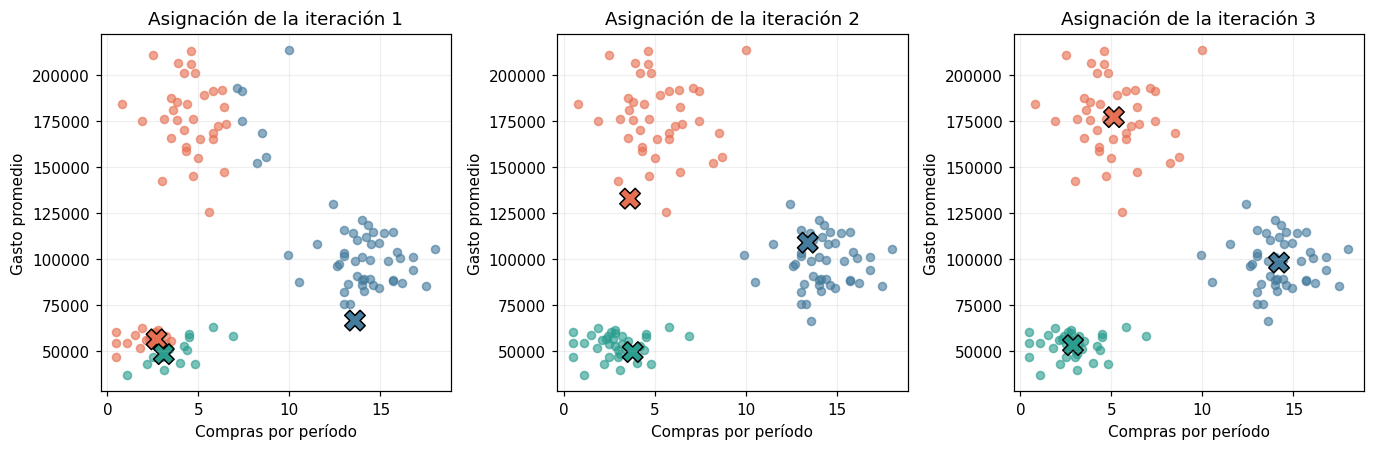

In [5]:
colores = ["#457B9D", "#E76F51", "#2A9D8F"]
pasos_mostrados = sorted(set([
    0,
    min(1, len(historial) - 1),
    min(2, len(historial) - 1),
    len(historial) - 1,
]))

fig, axes = plt.subplots(
    1,
    len(pasos_mostrados),
    figsize=(4.2 * len(pasos_mostrados), 4.2),
    squeeze=False,
)

for ax, indice_paso in zip(axes.flat, pasos_mostrados):
    paso = historial[indice_paso]
    etiquetas = paso["asignaciones"]
    centros_antes = escalador_demo.inverse_transform(
        paso["centroides_antes"]
    )

    for cluster in range(3):
        mascara = etiquetas == cluster
        ax.scatter(
            datos_clientes.loc[mascara, "frecuencia_compra"],
            datos_clientes.loc[mascara, "gasto_promedio"],
            color=colores[cluster],
            alpha=0.62,
            s=28,
        )

    ax.scatter(
        centros_antes[:, 0],
        centros_antes[:, 1],
        marker="X",
        s=180,
        color=colores,
        edgecolor="black",
        linewidth=1,
    )
    ax.set_title(f"Asignación de la iteración {indice_paso + 1}")
    ax.set_xlabel("Compras por período")
    ax.set_ylabel("Gasto promedio")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


Cada color indica el centroide más cercano en esa iteración. Las cruces son los centros antes de recalcularlos. Al moverse, algunos clientes cambian de grupo.

Los números de cluster solo permiten seguir cada centro durante el proceso. Si cambiáramos el orden de las cruces, cambiarían los números sin que por eso apareciera una jerarquía.


## 4. Calcular la asignación de un cliente

Observaremos las distancias de un cliente a los tres centroides finales. La menor distancia debe coincidir con su asignación.


In [6]:
centroides_finales_demo = historial[-1]["centroides_despues"]
cliente_elegido = 0

distancias_cliente = pairwise_distances(
    X_demo[[cliente_elegido]],
    centroides_finales_demo,
).ravel()

tabla_distancias = pd.DataFrame({
    "centroide": [0, 1, 2],
    "distancia": distancias_cliente,
})
tabla_distancias["es_el_mas_cercano"] = (
    tabla_distancias["distancia"]
    == tabla_distancias["distancia"].min()
)

print(
    "Cliente:",
    datos_clientes.loc[cliente_elegido, "cliente"],
)
print(
    datos_clientes.loc[
        cliente_elegido,
        ["frecuencia_compra", "gasto_promedio"],
    ].to_string()
)
tabla_distancias.round(4)


Cliente: CLI-001
frecuencia_compra       14.10
gasto_promedio      82,400.00


,centroide,distancia,es_el_mas_cercano
0,0,0.30,True
1,1,2.50,False
2,2,2.21,False


La distancia se calculó en el espacio escalado, no mezclando directamente compras con pesos. El cliente pertenece al cluster cuyo valor es menor.

La misma regla se aplica aunque usemos cinco, diez o más variables: cada fila sigue siendo un punto, pero el espacio ya no puede dibujarse con facilidad.


## 5. Ajustar el pipeline completo

Ahora agruparemos con las cinco variables de comportamiento. El pipeline aprenderá el escalado y luego ajustará K-Means con `k = 3`.

Usaremos `n_init=20` para probar distintas posiciones iniciales y conservar la solución de menor inercia. `random_state` hace reproducible el experimento.


In [7]:
pipeline_clientes = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=3,
        n_init=20,
        random_state=26,
    )),
])

datos_clientes["cluster"] = pipeline_clientes.fit_predict(
    X_clientes
)

modelo_clientes = pipeline_clientes.named_steps["kmeans"]
escalador_clientes = pipeline_clientes.named_steps["scaler"]

pd.DataFrame({
    "atributo": [
        "labels_",
        "cluster_centers_",
        "inertia_",
        "n_iter_",
    ],
    "significado": [
        "cluster asignado a cada fila",
        "coordenadas de los centroides",
        "suma de distancias cuadradas a los centros",
        "iteraciones realizadas en la mejor ejecución",
    ],
    "valor_o_forma": [
        str(modelo_clientes.labels_.shape),
        str(modelo_clientes.cluster_centers_.shape),
        f"{modelo_clientes.inertia_:.3f}",
        str(modelo_clientes.n_iter_),
    ],
})


,atributo,significado,valor_o_forma
0,labels_,cluster asignado a cada fila,"(120,)"
1,cluster_centers_,coordenadas de los centroides,"(3, 5)"
2,inertia_,suma de distancias cuadradas a los centros,97.271
3,n_iter_,iteraciones realizadas en la mejor ejecución,2


`cluster_centers_` está expresado en la escala estandarizada. Esto sirve para comparar posiciones relativas, pero no es la forma más clara de comunicar cuánto compran o gastan los clientes.

Podemos invertir el escalado para recuperar las unidades originales.


In [8]:
centroides_originales = pd.DataFrame(
    escalador_clientes.inverse_transform(
        modelo_clientes.cluster_centers_
    ),
    columns=variables_comportamiento,
)
centroides_originales.index.name = "cluster"

tamanos = (
    datos_clientes["cluster"]
    .value_counts()
    .sort_index()
    .rename("clientes")
)

perfiles = (
    datos_clientes
    .groupby("cluster")[variables_comportamiento]
    .mean()
)

resumen_clusters = (
    centroides_originales
    .join(tamanos)
    [["clientes"] + variables_comportamiento]
    .round(1)
)

resumen_clusters


,clientes,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas
cluster,,,,,,
0,45,14.20,"98,035.60",7.90,32.60,5.50
1,35,2.90,"53,280.00",86.60,54.60,2.30
2,40,5.10,"176,935.00",27.80,20.30,3.60


Como un centroide es el promedio de los puntos asignados, sus coordenadas en unidades originales coinciden con los promedios de cada grupo, salvo pequeñas diferencias de redondeo.

Recién a partir de esta tabla podemos proponer nombres como “actividad frecuente”, “compras ocasionales de monto alto” o “baja actividad reciente”. Los nombres son interpretaciones humanas; K-Means solo devolvió `0`, `1` y `2`.


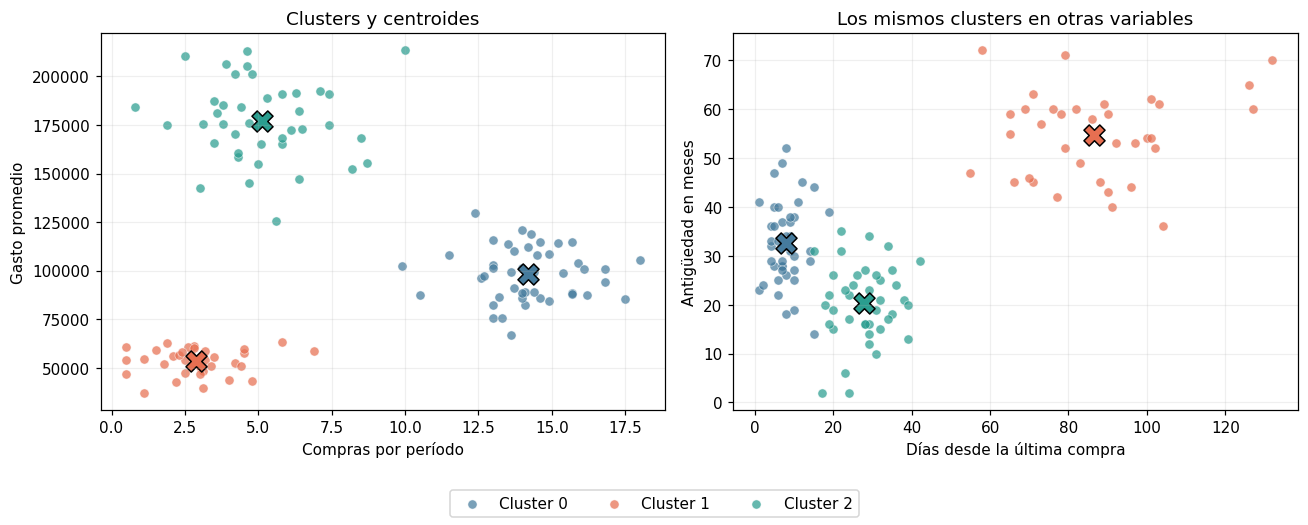

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for cluster, grupo in datos_clientes.groupby("cluster"):
    color = colores[cluster]
    axes[0].scatter(
        grupo["frecuencia_compra"],
        grupo["gasto_promedio"],
        color=color,
        label=f"Cluster {cluster}",
        alpha=0.72,
        edgecolor="white",
        linewidth=0.4,
    )
    axes[1].scatter(
        grupo["dias_ultima_compra"],
        grupo["antiguedad_meses"],
        color=color,
        label=f"Cluster {cluster}",
        alpha=0.72,
        edgecolor="white",
        linewidth=0.4,
    )

for cluster, centro in centroides_originales.iterrows():
    axes[0].scatter(
        centro["frecuencia_compra"],
        centro["gasto_promedio"],
        marker="X",
        s=190,
        color=colores[cluster],
        edgecolor="black",
        linewidth=1,
    )
    axes[1].scatter(
        centro["dias_ultima_compra"],
        centro["antiguedad_meses"],
        marker="X",
        s=190,
        color=colores[cluster],
        edgecolor="black",
        linewidth=1,
    )

axes[0].set_xlabel("Compras por período")
axes[0].set_ylabel("Gasto promedio")
axes[0].set_title("Clusters y centroides")
axes[0].grid(alpha=0.2)

axes[1].set_xlabel("Días desde la última compra")
axes[1].set_ylabel("Antigüedad en meses")
axes[1].set_title("Los mismos clusters en otras variables")
axes[1].grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()


Las cruces representan los centroides en cada plano. El modelo utilizó cinco variables al mismo tiempo; por eso, los límites de los clusters no dependen únicamente de las dos columnas que muestra cada gráfico.

## 6. Verificar la inercia

`transform` devuelve la distancia de cada fila a cada centroide. Si tomamos, para cada cliente, la distancia al centro asignado, la elevamos al cuadrado y sumamos, recuperamos la inercia.


In [10]:
distancias_a_centros = pipeline_clientes.transform(X_clientes)
distancia_asignada = distancias_a_centros[
    np.arange(len(X_clientes)),
    modelo_clientes.labels_,
]
inercia_reconstruida = np.sum(distancia_asignada ** 2)

pd.DataFrame({
    "calculo": [
        "KMeans.inertia_",
        "Suma reconstruida",
        "Diferencia",
    ],
    "valor": [
        modelo_clientes.inertia_,
        inercia_reconstruida,
        abs(modelo_clientes.inertia_ - inercia_reconstruida),
    ],
})


,calculo,valor
0,KMeans.inertia_,97.27
1,Suma reconstruida,97.27
2,Diferencia,0.00


Una inercia menor indica grupos más compactos en el espacio utilizado. No significa automáticamente que sean más claros o útiles: siempre disminuye cuando agregamos suficientes centroides.


## 7. Asignar un cliente nuevo

Después del ajuste, `predict` no vuelve a descubrir los grupos. Aplica el mismo escalado y asigna el caso nuevo al centroide existente más cercano.


In [11]:
nuevo_cliente = pd.DataFrame({
    "frecuencia_compra": [12],
    "gasto_promedio": [105_000],
    "dias_ultima_compra": [7],
    "antiguedad_meses": [30],
    "categorias_compradas": [6],
})

cluster_nuevo = pipeline_clientes.predict(nuevo_cliente)[0]
distancias_nuevo = pipeline_clientes.transform(
    nuevo_cliente
).ravel()

pd.DataFrame({
    "cluster": range(3),
    "distancia_al_centroide": distancias_nuevo,
    "asignado": [
        cluster == cluster_nuevo
        for cluster in range(3)
    ],
}).round(4)


,cluster,distancia_al_centroide,asignado
0,0,0.56,True
1,1,4.17,False
2,2,2.60,False


El resultado no afirma qué “tipo verdadero” de cliente es. Indica qué perfil central, entre los tres aprendidos, queda más cerca según estas cinco variables.

Si el comportamiento del negocio cambia mucho con el tiempo, los centroides también pueden dejar de representar bien a los casos nuevos. Un modelo de segmentación necesita revisión, no solo una ejecución inicial.


## 8. Cambiar `k` cambia la organización

Compararemos soluciones de dos a cinco clusters sobre los mismos datos escalados. Al aumentar `k`, no se agrega simplemente un grupo independiente: pueden moverse varios centroides y cambiar muchas asignaciones.


In [12]:
X_clientes_escalado = escalador_clientes.transform(X_clientes)
modelos_por_k = {}
resumen_k = []

for k in range(2, 7):
    modelo_k = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=26,
    )
    etiquetas_k = modelo_k.fit_predict(
        X_clientes_escalado
    )
    modelos_por_k[k] = (modelo_k, etiquetas_k)

    tamanos_k = np.bincount(etiquetas_k)
    resumen_k.append({
        "k": k,
        "inercia": modelo_k.inertia_,
        "cluster_mas_pequeno": tamanos_k.min(),
        "cluster_mas_grande": tamanos_k.max(),
        "tamanos": ", ".join(map(str, sorted(tamanos_k))),
    })

pd.DataFrame(resumen_k).round(2)


,k,inercia,cluster_mas_pequeno,cluster_mas_grande,tamanos
0,2,262.08,35,85,"35, 85"
1,3,97.27,35,45,"35, 40, 45"
2,4,86.26,22,40,"22, 23, 35, 40"
3,5,76.80,18,35,"18, 22, 22, 23, 35"
4,6,69.78,12,27,"12, 13, 20, 23, 25, 27"


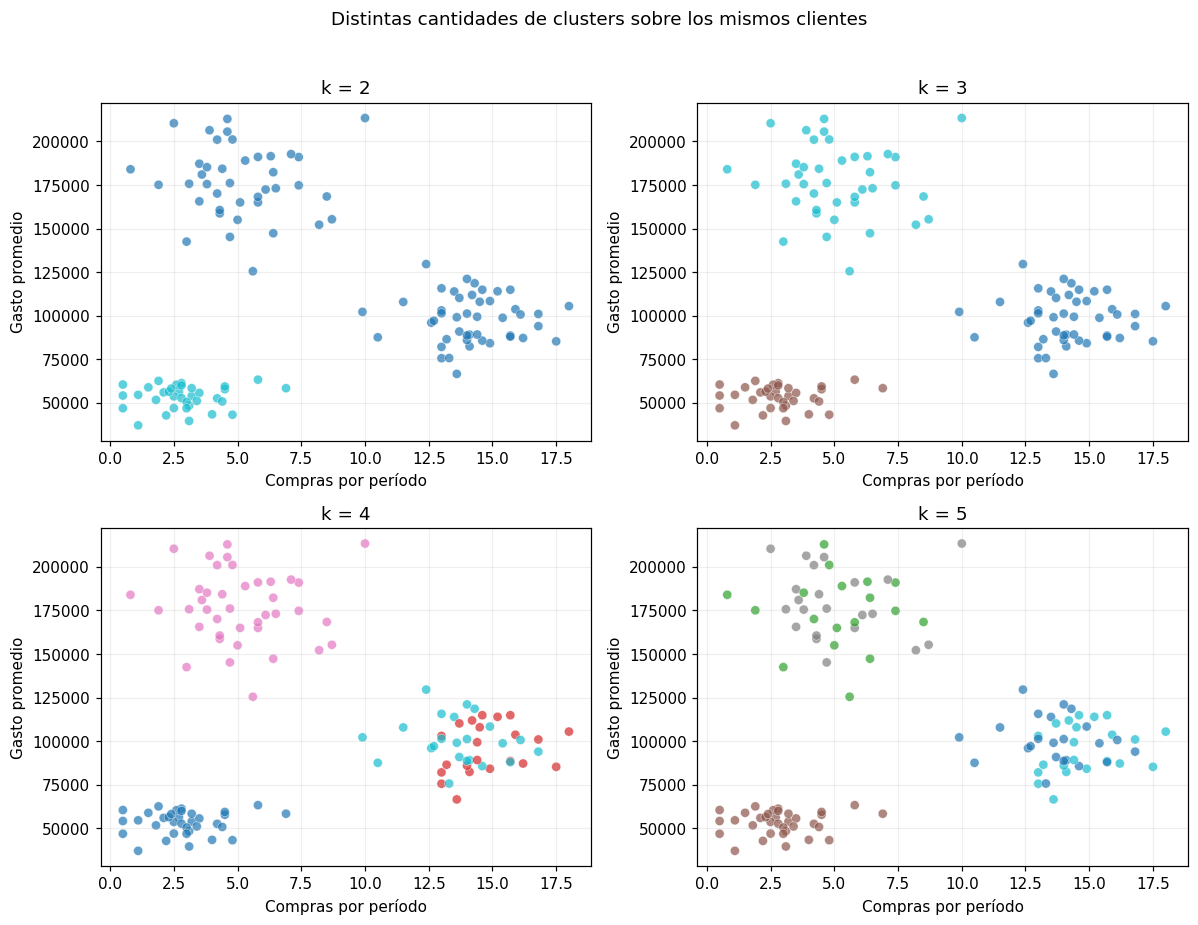

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.2))

for ax, k in zip(axes.flat, [2, 3, 4, 5]):
    modelo_k, etiquetas_k = modelos_por_k[k]
    ax.scatter(
        datos_clientes["frecuencia_compra"],
        datos_clientes["gasto_promedio"],
        c=etiquetas_k,
        cmap="tab10",
        alpha=0.7,
        edgecolor="white",
        linewidth=0.35,
    )
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Compras por período")
    ax.set_ylabel("Gasto promedio")
    ax.grid(alpha=0.2)

plt.suptitle(
    "Distintas cantidades de clusters sobre los mismos clientes",
    y=1.02,
)
plt.tight_layout()
plt.show()


Con pocos clusters obtenemos un resumen amplio. Con más clusters aparecen subdivisiones y grupos más pequeños. La visualización usa solo dos variables, aunque todos los modelos analizaron las cinco.

No podemos elegir `k` solo por cuántos colores se ven separados en este plano. Debemos revisar compactación, tamaños, perfiles, estabilidad y utilidad.


## 9. Construir el método del codo

Entrenaremos K-Means desde `k = 1` hasta `k = 9` usando exactamente el mismo preprocesamiento. También calcularemos cuánto se reduce la inercia al agregar cada nuevo cluster.


In [14]:
resultados_codo = []

for k in range(1, 10):
    modelo_k = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=26,
    )
    modelo_k.fit(X_clientes_escalado)
    resultados_codo.append({
        "k": k,
        "inercia": modelo_k.inertia_,
    })

resultados_codo = pd.DataFrame(resultados_codo)
resultados_codo["reduccion_absoluta"] = (
    -resultados_codo["inercia"].diff()
)
resultados_codo["reduccion_porcentual"] = (
    resultados_codo["reduccion_absoluta"]
    / resultados_codo["inercia"].shift(1)
)

resultados_codo.round(3)


,k,inercia,reduccion_absoluta,reduccion_porcentual
0,1,600.00,NaN,NaN
1,2,262.08,337.92,0.56
2,3,97.27,164.81,0.63
3,4,86.26,11.01,0.11
4,5,76.80,9.46,0.11
5,6,69.78,7.03,0.09
6,7,63.18,6.60,0.10
7,8,58.08,5.10,0.08
8,9,54.23,3.85,0.07


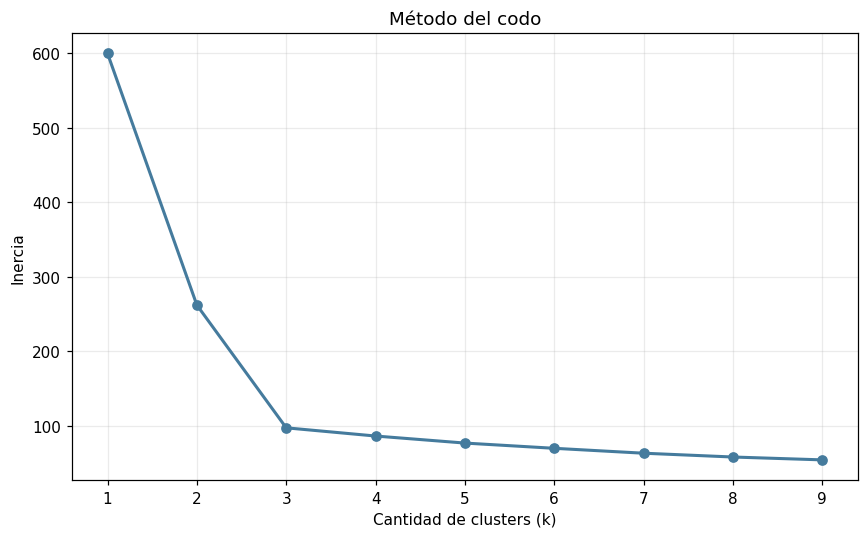

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    resultados_codo["k"],
    resultados_codo["inercia"],
    marker="o",
    color="#457B9D",
    linewidth=2,
)
ax.set_xticks(resultados_codo["k"])
ax.set_xlabel("Cantidad de clusters (k)")
ax.set_ylabel("Inercia")
ax.set_title("Método del codo")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


La caída es grande durante los primeros pasos y luego se vuelve más gradual. En este conjunto didáctico, la curva ofrece una señal visible alrededor de tres clusters, coherente con los perfiles amplios que observamos.

Eso no convierte a `k = 3` en una verdad demostrada. El método del codo propone candidatos. Si el cambio de pendiente fuera ambiguo, tendría sentido comparar dos o tres valores cercanos y estudiar sus perfiles.

Además, la inercia de modelos entrenados con escalas diferentes no es directamente comparable. El gráfico debe construirse con el mismo conjunto de variables y el mismo preprocesamiento.


## 10. Comprobar el efecto del escalado

Repetiremos `k = 3` sin estandarizar. Como `gasto_promedio` contiene números mucho mayores que las otras columnas, esperamos que organice gran parte de las distancias.


In [16]:
modelo_sin_escalar = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=26,
)
cluster_sin_escalar = modelo_sin_escalar.fit_predict(
    X_clientes
)

comparacion_escala = pd.crosstab(
    datos_clientes["cluster"],
    cluster_sin_escalar,
    rownames=["Con escalado"],
    colnames=["Sin escalado"],
)

perfil_sin_escalar = (
    datos_clientes
    .assign(cluster_sin_escalar=cluster_sin_escalar)
    .groupby("cluster_sin_escalar")[variables_comportamiento]
    .mean()
    .round(1)
)

print("Cruce de asignaciones:")
print(comparacion_escala.to_string())
print("\nPerfiles sin escalado:")
perfil_sin_escalar


Cruce de asignaciones:
Sin escalado   0   1   2
Con escalado            
0             42   0   3
1              0   0  35
2              1  39   0

Perfiles sin escalado:


,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas
cluster_sin_escalar,,,,,
0,14.10,"100,446.50",8.60,32.70,5.50
1,5.10,"178,253.80",27.70,20.20,3.60
2,3.70,"54,807.90",80.20,52.60,2.60


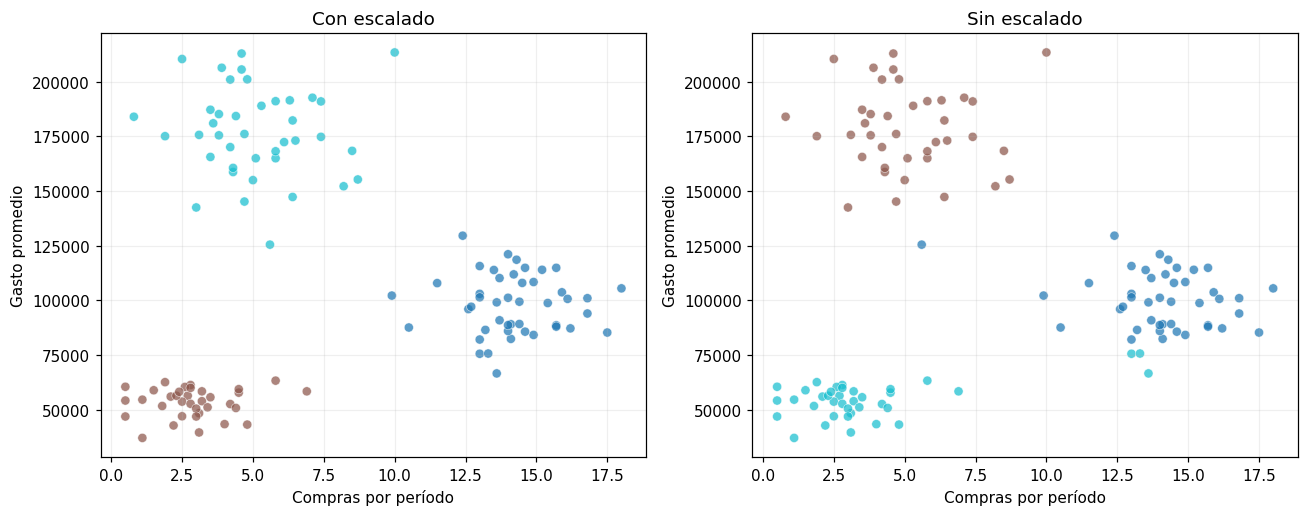

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(
    datos_clientes["frecuencia_compra"],
    datos_clientes["gasto_promedio"],
    c=datos_clientes["cluster"],
    cmap="tab10",
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
)
axes[0].set_title("Con escalado")

axes[1].scatter(
    datos_clientes["frecuencia_compra"],
    datos_clientes["gasto_promedio"],
    c=cluster_sin_escalar,
    cmap="tab10",
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
)
axes[1].set_title("Sin escalado")

for ax in axes:
    ax.set_xlabel("Compras por período")
    ax.set_ylabel("Gasto promedio")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


Sin escalado, la separación sigue sobre todo los niveles de gasto. Eso no es necesariamente incorrecto si la pregunta fuera segmentar únicamente por monto, pero no representa de forma equilibrada las cinco dimensiones elegidas.

Escalar no garantiza buenos clusters ni reemplaza el criterio sobre las variables. Evita que las unidades numéricas decidan por sí solas.


## 11. Revisar la influencia de la inicialización

K-Means puede llegar a soluciones distintas según sus centroides iniciales. Lo observaremos usando `k = 4`, una segmentación menos evidente, y una sola inicialización por ejecución.

Después compararemos con `n_init=20`, que prueba varios puntos de partida y conserva la solución de menor inercia.


In [18]:
resultados_inicializacion = []

for semilla in range(12):
    modelo_semilla = KMeans(
        n_clusters=4,
        n_init=1,
        random_state=semilla,
    ).fit(X_clientes_escalado)

    resultados_inicializacion.append({
        "random_state": semilla,
        "inercia": modelo_semilla.inertia_,
        "iteraciones": modelo_semilla.n_iter_,
    })

modelo_varios_inicios = KMeans(
    n_clusters=4,
    n_init=20,
    random_state=26,
).fit(X_clientes_escalado)

tabla_inicios = (
    pd.DataFrame(resultados_inicializacion)
    .sort_values("inercia")
    .reset_index(drop=True)
)

print(
    "Inercia con 20 inicializaciones:",
    round(modelo_varios_inicios.inertia_, 3),
)
tabla_inicios.round(3)


Inercia con 20 inicializaciones: 86.257


,random_state,inercia,iteraciones
0,3,86.26,3
1,11,86.40,4
2,10,87.81,3
3,2,87.81,4
4,7,88.49,3
5,0,88.77,4
6,8,89.03,4
7,5,89.34,4
8,4,90.59,6
9,1,90.80,3


Las ejecuciones con menor inercia encontraron una compactación mejor para el mismo valor de `k`. `n_init` reduce el riesgo de conservar por casualidad una solución deficiente, aunque no decide si cuatro clusters tienen significado práctico.

`random_state` no mejora el modelo: permite reproducir el experimento y documentar qué ocurrió.


## 12. Observar cuándo K-Means funciona y cuándo se complica

El capítulo advierte que K-Means funciona mejor con grupos compactos alrededor de centros. Prepararemos tres situaciones:

- grupos aproximadamente redondeados;
- dos formas curvas en media luna;
- dos grupos compactos a los que agregamos valores extremos.

En todos los casos pediremos dos clusters. Que el algoritmo entregue dos colores no significa que la división sea adecuada.


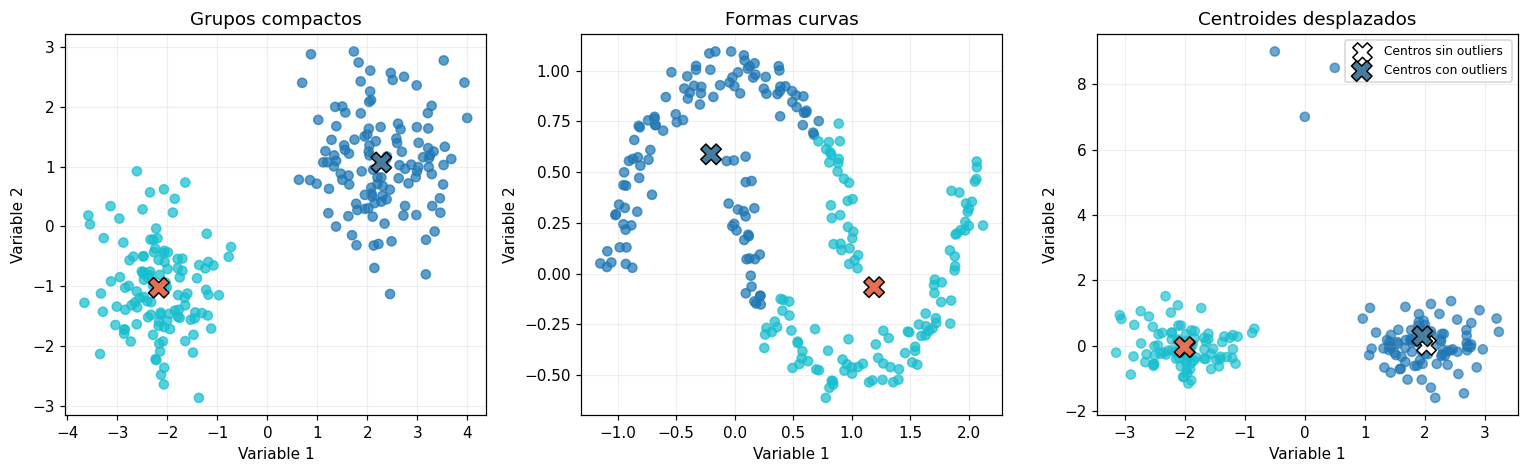

In [19]:
X_compacto, _ = make_blobs(
    n_samples=240,
    centers=[(-2.2, -1.0), (2.2, 1.2)],
    cluster_std=[0.7, 0.8],
    random_state=26,
)

X_lunas, _ = make_moons(
    n_samples=240,
    noise=0.07,
    random_state=26,
)

X_base_outlier, _ = make_blobs(
    n_samples=180,
    centers=[(-2, 0), (2, 0)],
    cluster_std=0.55,
    random_state=26,
)
outliers = np.array([[0, 7], [0.5, 8.5], [-0.5, 9]])
X_con_outliers = np.vstack([X_base_outlier, outliers])

modelo_compacto = KMeans(
    n_clusters=2, n_init=20, random_state=26
).fit(X_compacto)
modelo_lunas = KMeans(
    n_clusters=2, n_init=20, random_state=26
).fit(X_lunas)
modelo_base = KMeans(
    n_clusters=2, n_init=20, random_state=26
).fit(X_base_outlier)
modelo_outliers = KMeans(
    n_clusters=2, n_init=20, random_state=26
).fit(X_con_outliers)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

axes[0].scatter(
    X_compacto[:, 0],
    X_compacto[:, 1],
    c=modelo_compacto.labels_,
    cmap="tab10",
    alpha=0.72,
)
axes[0].scatter(
    modelo_compacto.cluster_centers_[:, 0],
    modelo_compacto.cluster_centers_[:, 1],
    marker="X",
    s=180,
    color=["#457B9D", "#E76F51"],
    edgecolor="black",
)
axes[0].set_title("Grupos compactos")

axes[1].scatter(
    X_lunas[:, 0],
    X_lunas[:, 1],
    c=modelo_lunas.labels_,
    cmap="tab10",
    alpha=0.72,
)
axes[1].scatter(
    modelo_lunas.cluster_centers_[:, 0],
    modelo_lunas.cluster_centers_[:, 1],
    marker="X",
    s=180,
    color=["#457B9D", "#E76F51"],
    edgecolor="black",
)
axes[1].set_title("Formas curvas")

axes[2].scatter(
    X_con_outliers[:, 0],
    X_con_outliers[:, 1],
    c=modelo_outliers.labels_,
    cmap="tab10",
    alpha=0.65,
)
axes[2].scatter(
    modelo_base.cluster_centers_[:, 0],
    modelo_base.cluster_centers_[:, 1],
    marker="X",
    s=160,
    color="white",
    edgecolor="black",
    label="Centros sin outliers",
)
axes[2].scatter(
    modelo_outliers.cluster_centers_[:, 0],
    modelo_outliers.cluster_centers_[:, 1],
    marker="X",
    s=180,
    color=["#457B9D", "#E76F51"],
    edgecolor="black",
    label="Centros con outliers",
)
axes[2].set_title("Centroides desplazados")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


En los grupos compactos, un centro representa razonablemente cada conjunto. En las medias lunas, K-Means corta las formas porque no puede describirlas mediante centros simples. En el tercer gráfico, los valores extremos desplazan los centroides construidos con promedios.

Otras dificultades aparecen con grupos de tamaños o densidades muy diferentes y con variables categóricas codificadas cuya distancia puede no tener un significado claro. Además, K-Means obliga a que todos los puntos pertenezcan a algún cluster, incluso si están muy lejos de cualquier centro.


## 13. Actividad modificable

Probá una segmentación propia sobre los clientes. Podés cambiar:

- las columnas de `variables_actividad`;
- `cantidad_clusters`;
- el uso de escalado;
- la cantidad de inicializaciones.

Después compará la inercia, los tamaños y los perfiles. No busques solamente la menor inercia: preguntate si los grupos describen algo comprensible y útil.


In [20]:
# Modificá estas opciones.
variables_actividad = [
    "frecuencia_compra",
    "gasto_promedio",
    "dias_ultima_compra",
]
cantidad_clusters = 3
usar_escalado = True
cantidad_inicializaciones = 20

X_actividad = datos_clientes[variables_actividad]

if usar_escalado:
    transformador_actividad = StandardScaler()
    X_actividad_modelo = transformador_actividad.fit_transform(
        X_actividad
    )
else:
    X_actividad_modelo = X_actividad.to_numpy()

modelo_actividad = KMeans(
    n_clusters=cantidad_clusters,
    n_init=cantidad_inicializaciones,
    random_state=26,
)
grupos_actividad = modelo_actividad.fit_predict(
    X_actividad_modelo
)

resumen_actividad = (
    datos_clientes
    .assign(grupo_actividad=grupos_actividad)
    .groupby("grupo_actividad")[variables_actividad]
    .agg(["count", "mean"])
    .round(1)
)

print("Inercia:", round(modelo_actividad.inertia_, 3))
resumen_actividad


Inercia: 33.659


frecuencia_compra       gasto_promedio             \
                            count  mean          count       mean   
grupo_actividad                                                     
0                              45 14.20             45  98,035.60   
1                              35  2.90             35  53,280.00   
2                              40  5.10             40 176,935.00   

                dias_ultima_compra        
                             count  mean  
grupo_actividad                           
0                               45  7.90  
1                               35 86.60  
2                               40 27.80

## 14. Una guía de interpretación

Al presentar un agrupamiento conviene documentar:

- qué pregunta exploratoria se formuló;
- qué variables se incluyeron y cuáles quedaron afuera;
- cómo se trataron faltantes, categorías, escalas y valores extremos;
- qué valores de `k` se compararon;
- qué mostraron la inercia y el método del codo;
- cuántos casos tiene cada cluster;
- qué perfiles aparecen en unidades originales;
- si la solución es estable ante cambios razonables;
- qué utilidad concreta tiene la segmentación;
- qué limitaciones impiden tratar los clusters como categorías verdaderas.

Una formulación prudente sería:

> Con estas cinco variables, este escalado y `k = 3`, K-Means sugiere tres perfiles de comportamiento.

No corresponde afirmar que el algoritmo descubrió tres tipos naturales y definitivos de personas.


## 15. Síntesis

En este cuaderno:

- retomamos clientes sin etiquetas;
- reconstruimos la asignación al centroide más cercano;
- movimos centroides mediante promedios sucesivos;
- observamos la estabilización del algoritmo;
- interpretamos distancias en un espacio escalado;
- ajustamos escalado y K-Means dentro de un pipeline;
- recuperamos centroides en unidades originales;
- comprobamos la relación entre distancias e inercia;
- asignamos un caso nuevo sin recalcular los centros;
- comparamos varias cantidades de clusters;
- construimos el método del codo;
- comprobamos que el escalado cambia la segmentación;
- observamos el efecto de distintas inicializaciones;
- analizamos formas curvas y valores extremos;
- distinguimos compactación matemática de utilidad práctica.

K-Means propone una forma de resumir los datos alrededor de centros. La calidad del resultado depende tanto del algoritmo como de las variables, el preprocesamiento, `k` y la interpretación posterior.


## Para pensar

1. ¿Por qué el centroide de un cluster no tiene que coincidir con un cliente real?
2. ¿Qué ocurriría con las distancias si `gasto_promedio` se utilizara en pesos y las demás variables quedaran sin escalar?
3. ¿Por qué la inercia no permite elegir automáticamente el mayor valor posible de `k`?
4. ¿Qué información complementarías con el método del codo antes de decidir la cantidad de clusters?
5. ¿Por qué K-Means puede dividir mal dos grupos con forma de media luna aunque visualmente sean fáciles de reconocer?
